# Script to check the transversal latents

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

import pandas as pd
import os 
import cv2

from dataset import PineappleCountDataset
from vae.vq_vae import VQVAE
from utils_tools import plot_samples, load_models

In [3]:
import warnings
import matplotlib.cbook

warnings.filterwarnings("ignore")

In [4]:
device = "cuda"

In [5]:
checkpoints_by_stage = {
    'last': {
        'Epoch_0': '/home/rtxmsi1/Downloads/VAE_training-master (2)/checkpoints/vqvae/weights_ck_0.pt',
        'Epoch_200': '/home/rtxmsi1/Downloads/VAE_training-master (2)/checkpoints/vqvae/weights_ck_199.pt',
    }
}

models = load_models(VAE=VQVAE, device=device, checkpoints_by_stage=checkpoints_by_stage)

In [6]:
dataset_path = "/home/rtxmsi1/Downloads/VAE_training-master (2)/VERTICAL_IMAGES_FG_BG_FULL_LABELS"
csv_path = "/home/rtxmsi1/Downloads/VAE_training-master (2)/DATASET.csv"

In [7]:
df = pd.read_csv(csv_path)
dataset_pineapple = PineappleCountDataset(train=True, train_ratio=0.3, 
                                          root_dir=dataset_path,
                                          resize_shape=(256, 256),
                                          dataframe=df)

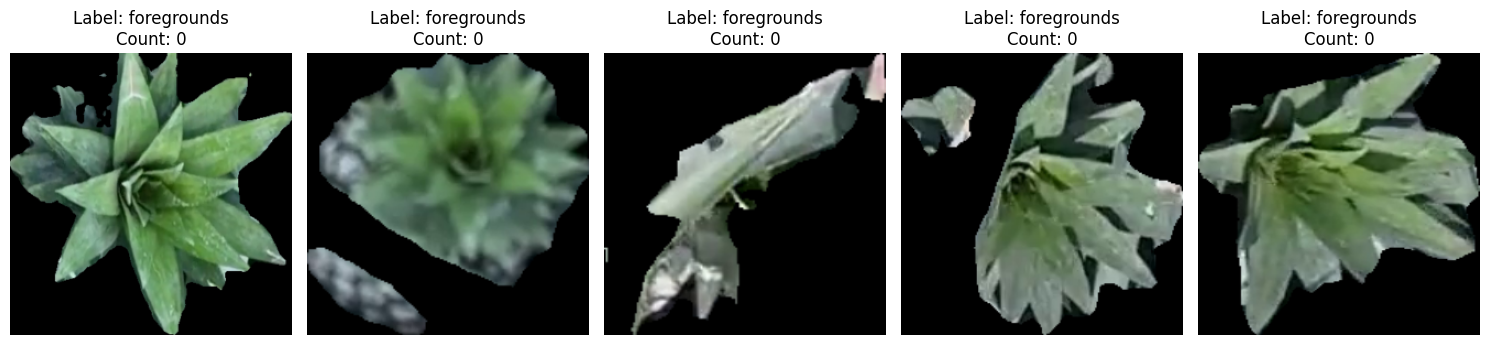

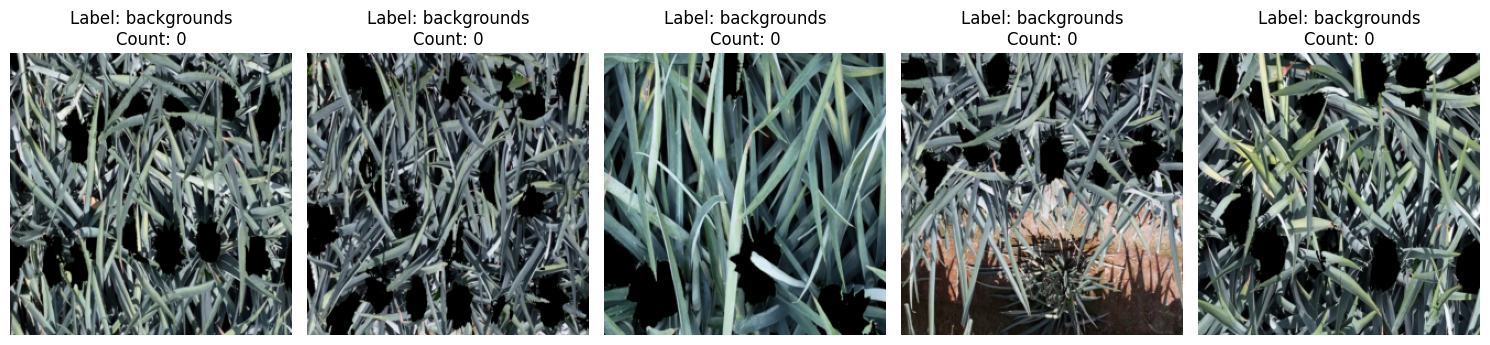

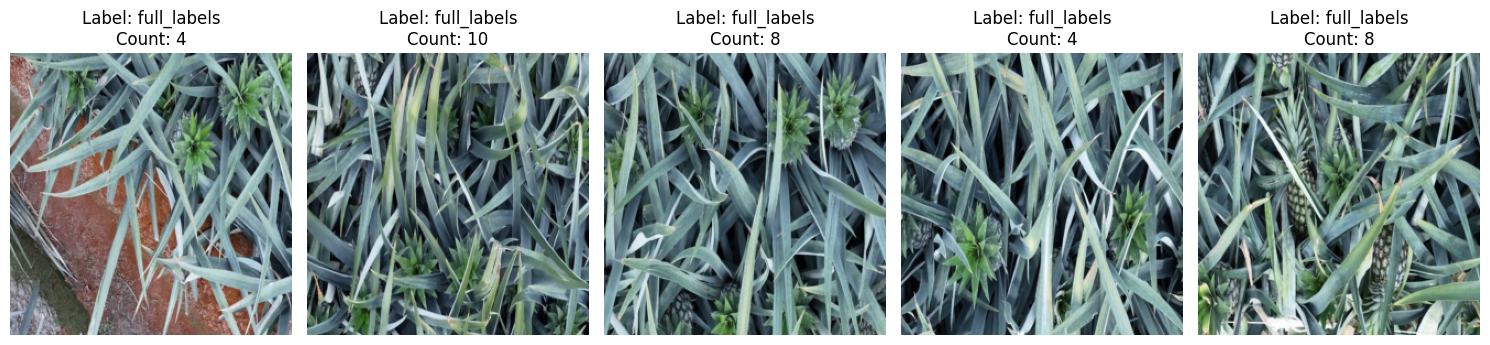

In [8]:
# Plot 5 foreground samples
plot_samples(dataset_pineapple, n=5, sample_type='foreground')
# Plot 5 background samples
plot_samples(dataset_pineapple, n=5, sample_type='background')
# Plot 5 full samples
plot_samples(dataset_pineapple, n=5, sample_type='full')

In [21]:
import matplotlib.pyplot as plt
import numpy as np
import torch

def visualize_latent_traversal_vqvae(model, input_tensor, noise, device, steps=10, scale=10.0, max_channels=8, model_name=''):
    """
    Visualize latent traversals for a spatial VAE using the same input image.
    
    Args:
        model: Trained VAE model with encoder and decoder.
        input_tensor: Tensor of shape (1, C, H, W), already moved to device.
        device: Torch device (e.g., 'cuda' or 'cpu').
        steps: Number of traversal steps per latent channel.
        scale: Range for traversal values (from -scale to +scale).
        max_channels: Max number of latent channels to visualize.
        model_name: String for figure title.
    """
    model.eval()
    model.to(device)

    with torch.no_grad():
        latent = model.encoder(input_tensor)
        original_latent = latent.clone()

        latent_channels = latent.shape[1]
        h_center = latent.shape[2] // 2
        w_center = latent.shape[3] // 2

        channels_to_show = min(latent_channels, max_channels)

        # For the original image
        input_np = input_tensor.squeeze().cpu().numpy()
        plt.figure(figsize=(3, 3))
        if input_np.ndim == 2:
            plt.imshow(np.clip(input_np, 0.0, 1.0), cmap='gray')
        else:
            img = np.transpose(input_np, (1, 2, 0))
            plt.imshow(np.clip(img, 0.0, 1.0))
        plt.title(f"Original Image ({model_name})")
        plt.axis('off')
        plt.show()

        # Latent traversal plots
        fig, axs = plt.subplots(channels_to_show, steps, figsize=(steps * 2, channels_to_show * 2))

        sorted_data = np.sort(np.random.normal(loc=0.0, scale=scale, size=steps))

        for i in range(channels_to_show):
            
            for j, alpha in enumerate(sorted_data):
                modified_latent = original_latent.clone()
                modified_latent[0, i, h_center, w_center] = alpha
                z_q, _, _, _, _ = model.vq_layer(modified_latent)
                reconstruction = model.decoder(z_q).cpu().squeeze().numpy()
                ax = axs[i, j] if channels_to_show > 1 else axs[j]
                if reconstruction.ndim == 2:
                    ax.imshow(np.clip(reconstruction, 0.0, 1.0), cmap='gray')
                else:
                    recon_img = np.transpose(reconstruction, (1, 2, 0))
                    ax.imshow(np.clip(recon_img, 0.0, 1.0))
                ax.set_title(f"{alpha:.2f}", fontsize=8)
                ax.axis('off')

        fig.suptitle(f"Latent Traversals ({model_name}) at Spatial Position ({h_center}, {w_center})")
        plt.tight_layout()
        plt.show()



def visualize_all_models(models, dataloader, device, key, steps=10, scale=10):
    # Extract one image from the dataloader
    for batch in dataloader:
        input_tensor = batch['image'].to(device)
        if input_tensor.dim() == 3:
            input_tensor = input_tensor.unsqueeze(0)
            batch_size, _, height, width = input_tensor.shape
            noise = torch.randn((batch_size, 4, height // 8, width // 8), device=device)
        else:
            input_tensor = input_tensor[0].unsqueeze(0)  # use first image in batch
            batch_size, _, height, width = input_tensor.shape
            noise = torch.randn((batch_size, 4, height // 8, width // 8), device=device)
        break

    # Apply same image to each model
    for model_name, model in models[key].items():
        print(f"Visualizing: {model_name}")
        visualize_latent_traversal_vqvae(model, input_tensor, noise, device, model_name=model_name, steps=steps, scale=scale)


In [13]:
label_names = dataset_pineapple.label_to_text
label_names

{0: 'backgrounds', 1: 'foregrounds', 2: 'full_labels'}

In [14]:
filtered_test_dataset = [sample for sample in dataset_pineapple if sample['label'] == 2]

In [15]:
import random
filtered_test_dataset = random.sample(filtered_test_dataset, len(filtered_test_dataset))

In [16]:
dataloader = filtered_test_dataset

## Latent transversal

To visualize how the output of a VAE changes as you manipulate individual latent channels at a specific spatial location (center of the latent feature map). We pick the center pixel of the image in one channel and maintains the other static.

- Our VAE encode the latent as (batch_size, latent_channels, latent_height, latent_width)
- The row represents the channel and column the step change of the latent center height and width, for 7 step from -3 to 3

In [17]:
data = np.random.normal(loc=0.0, scale=100, size=10)
sorted_data = np.sort(data)
sorted_data

array([-225.97787129, -186.18625423, -124.47379176,  -84.72148821,
        -72.13661744,  -63.64181409,  -33.39672615,  -32.43773965,
         10.81251674,  240.45051826])

Visualizing: Epoch_0


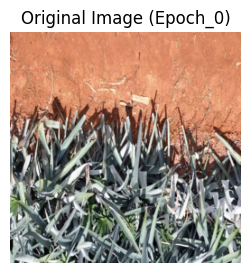

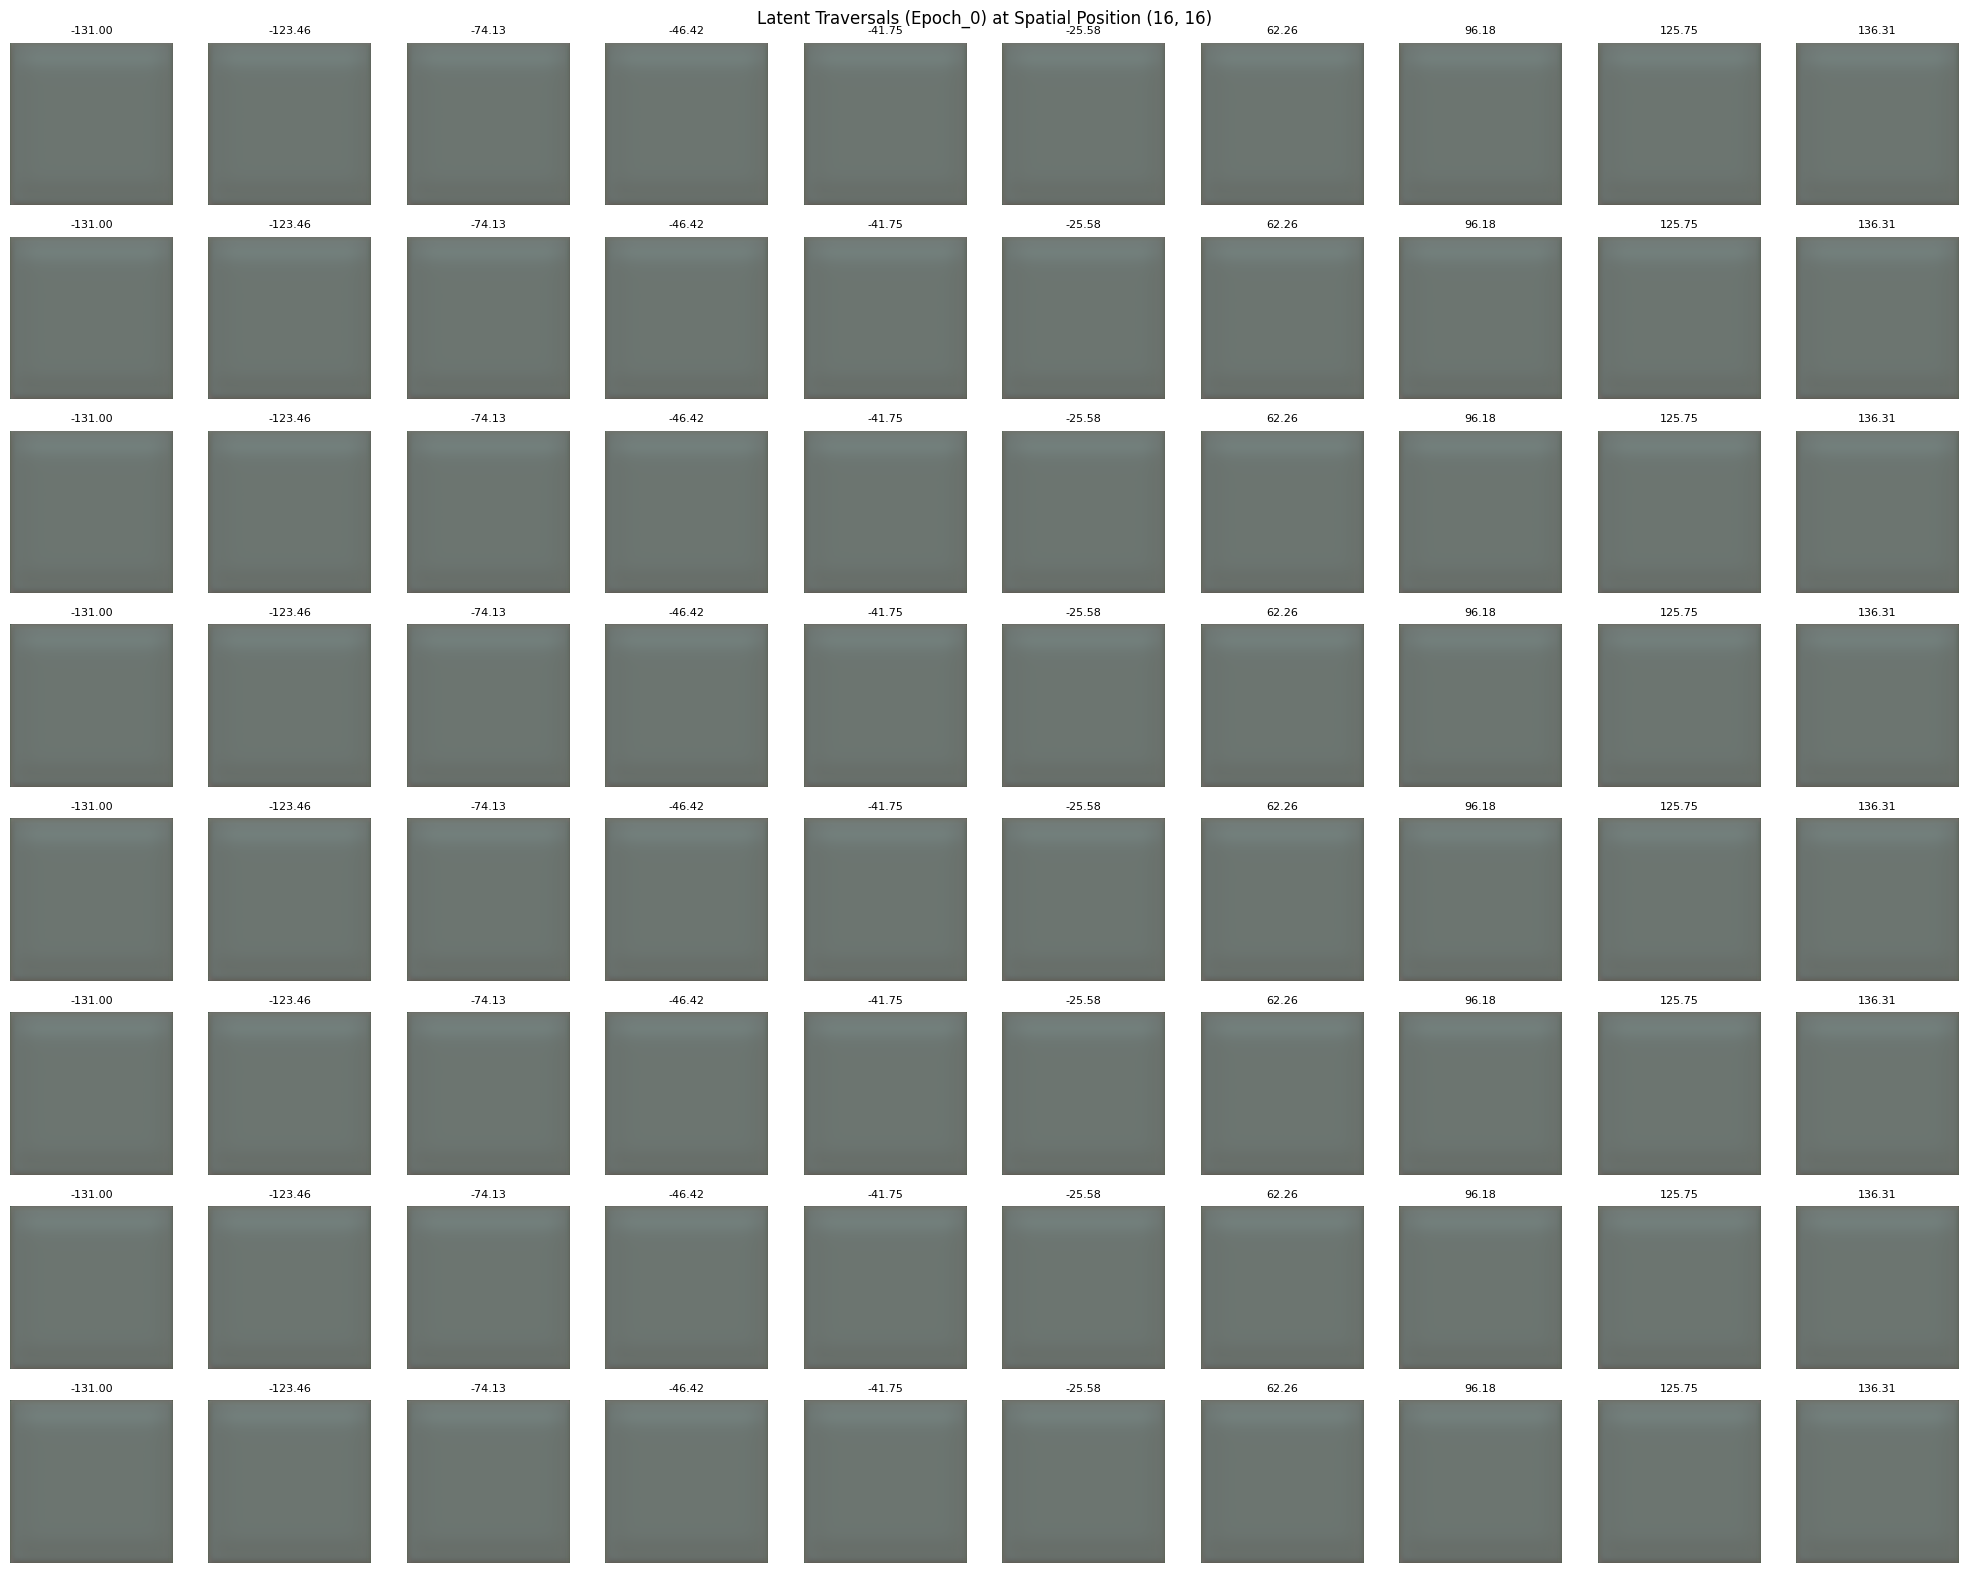

Visualizing: Epoch_200


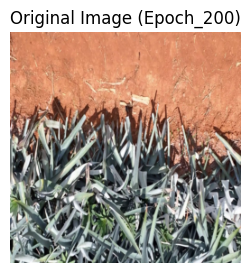

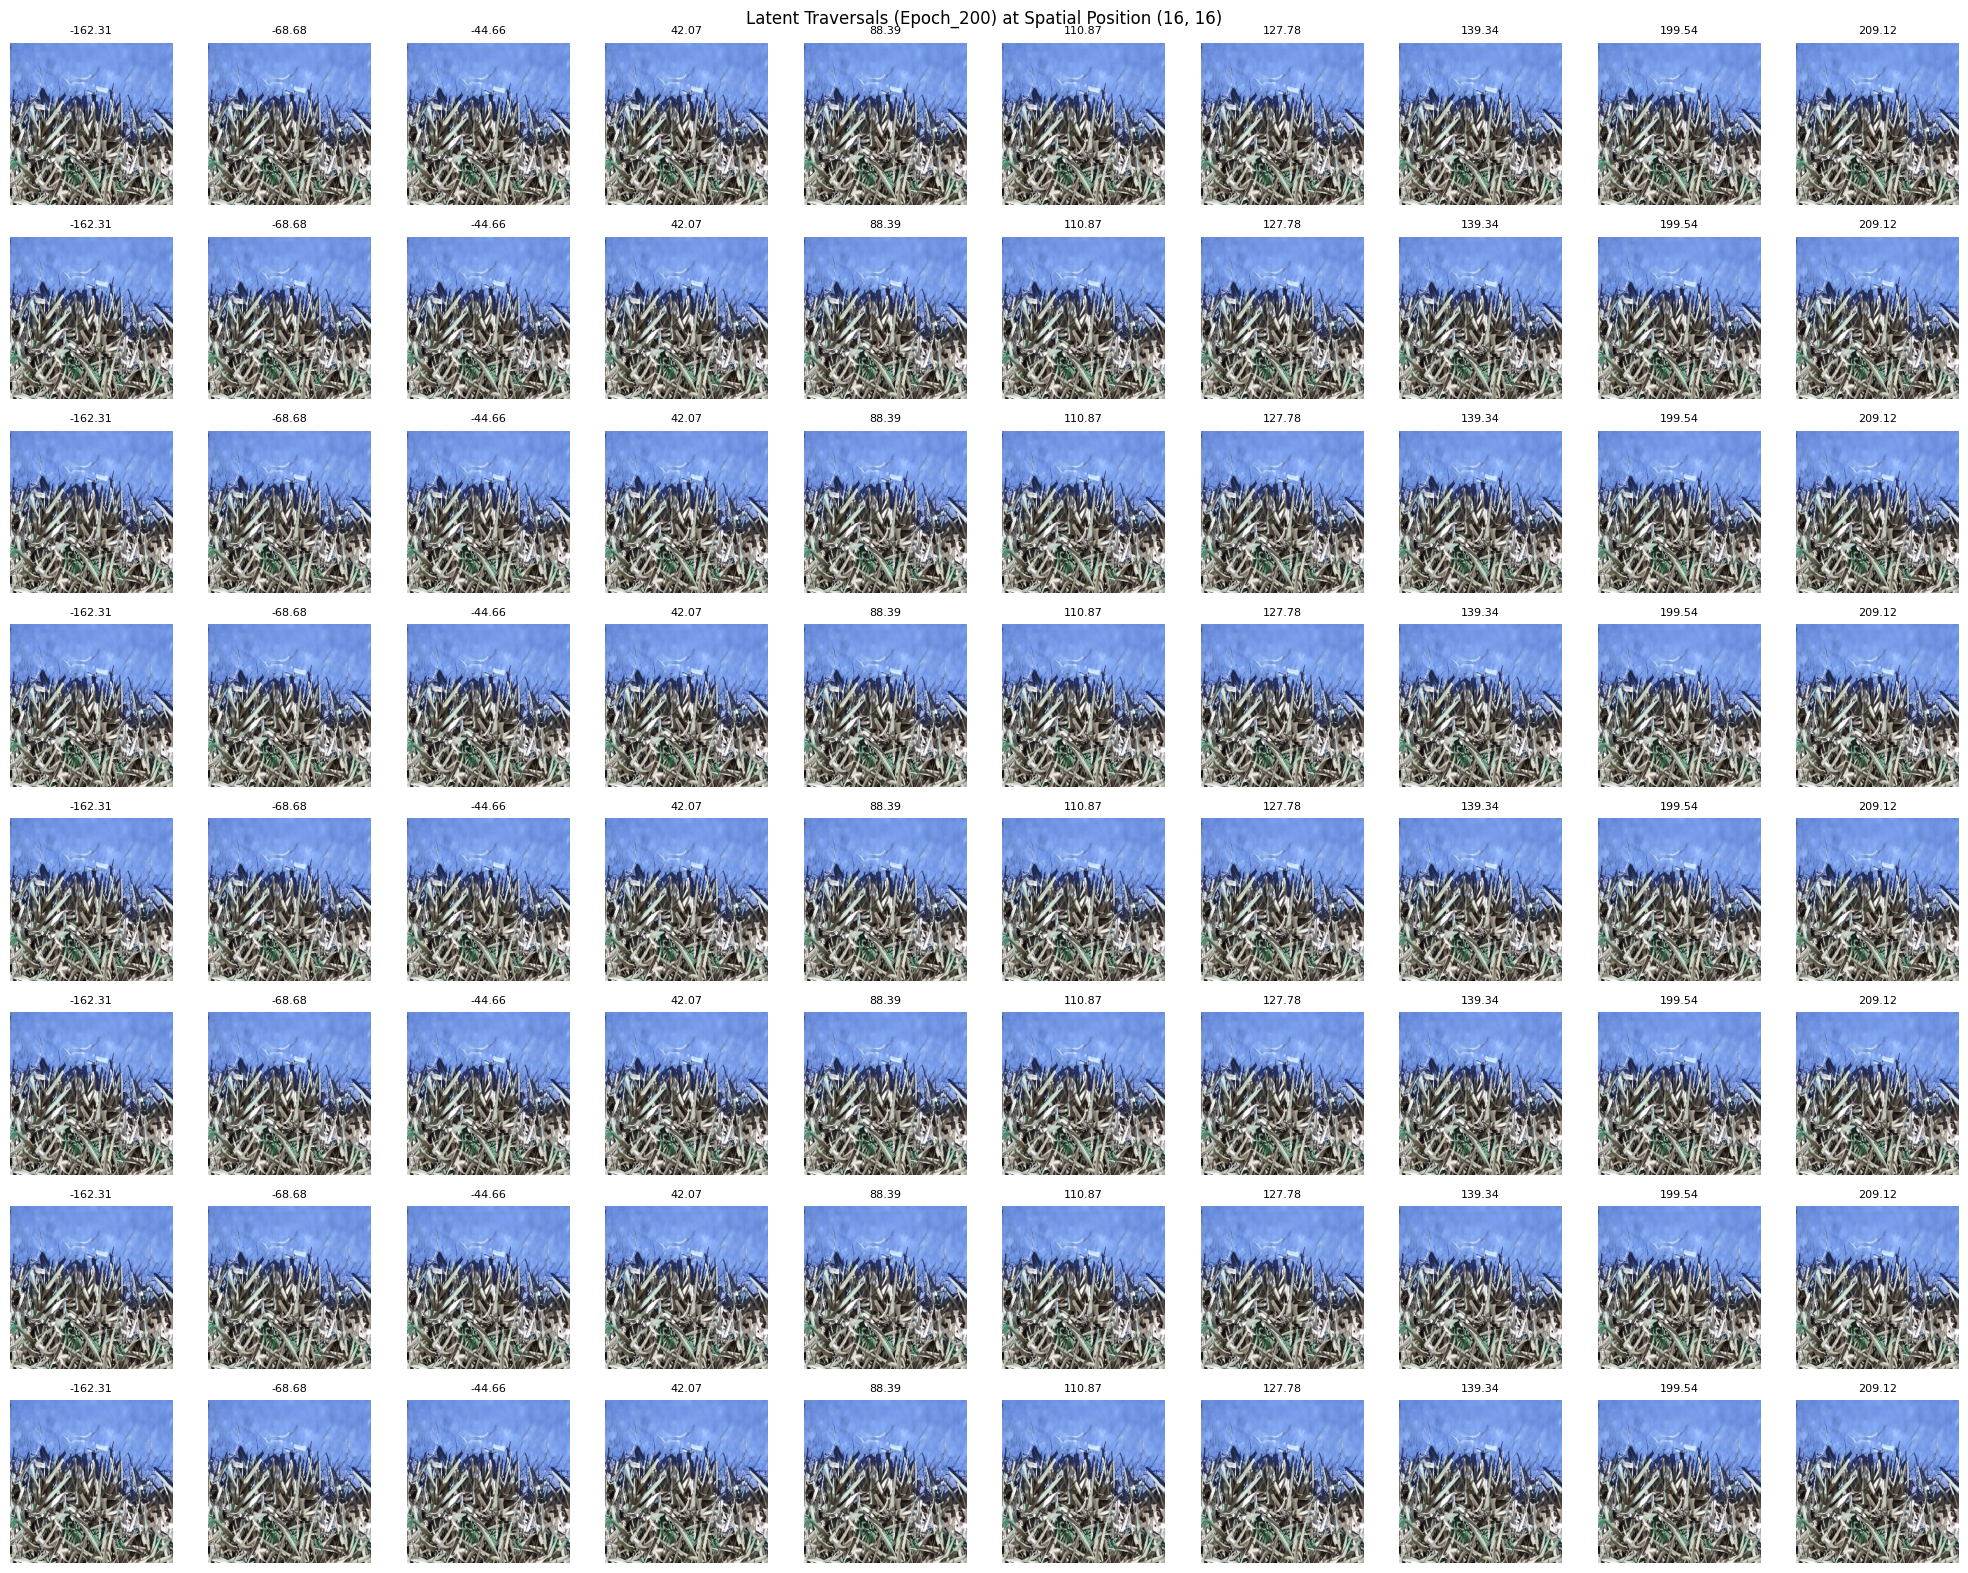

In [22]:
visualize_all_models(models, dataloader, device, key="last", steps=10, scale=100)